In [25]:
import torch
import nltk
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
import re
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchtext.vocab import GloVe
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np


### Data description

#### Import dataset

In [ ]:
#Download the dataset from:
#https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

path = r"..\data\IMDB Dataset.csv"
imdb_data = pd.read_csv(path)

#### Data description

In [3]:
imdb_data.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [4]:
imdb_data['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [5]:
word_counts = imdb_data['review'].apply(lambda x: len(x.split()))
word_counts.describe()

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review, dtype: float64

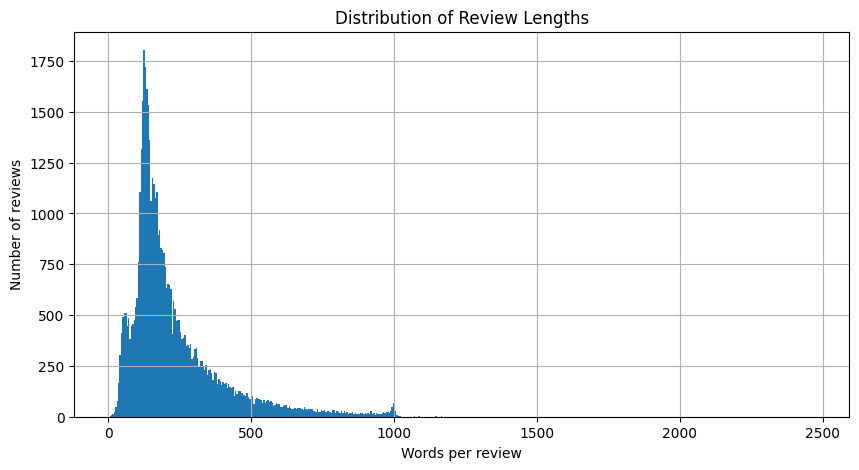

In [6]:
word_counts.hist(bins=500, figsize=(10,5))
plt.xlabel('Words per review')
plt.ylabel('Number of reviews')
plt.title('Distribution of Review Lengths')
plt.show()

### Data cleaning

#### Remove duplicates

In [7]:
imdb_data_clean = imdb_data.drop_duplicates()
imdb_data_clean.describe()

,review,sentiment
count,49582,49582
unique,49582,2
top,One of the other reviewers has mentioned that ...,positive
freq,1,24884


#### Remove HTML tags

In [8]:
def html_tags_cleaning(review : str):
    return re.sub(r"<.*?>", "", review)

imdb_data_clean['review'] = imdb_data_clean['review'].apply(html_tags_cleaning)
imdb_data_clean


C:\Users\Facundo\AppData\Local\Temp\ipykernel_508\2000925089.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['review'] = imdb_data_clean['review'].apply(html_tags_cleaning)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


### Data preprocessing

#### Change label to int (1 or 0)

In [9]:
imdb_data_clean['sentiment'] = imdb_data_clean['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)
imdb_data_clean

C:\Users\Facundo\AppData\Local\Temp\ipykernel_508\335119053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['sentiment'] = imdb_data_clean['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)


,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. The filming tec...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


#### Reviews to lowercase

In [10]:
imdb_data_clean['review'] = imdb_data_clean['review'].apply(lambda x: str.lower(x))
imdb_data_clean

C:\Users\Facundo\AppData\Local\Temp\ipykernel_508\1640804236.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['review'] = imdb_data_clean['review'].apply(lambda x: str.lower(x))


,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. the filming tec...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1
...,...,...
49995,i thought this movie did a down right good job...,1
49996,"bad plot, bad dialogue, bad acting, idiotic di...",0
49997,i am a catholic taught in parochial elementary...,0
49998,i'm going to have to disagree with the previou...,0


#### Tokenize words

In [11]:
nltk.download("punkt")
nltk.download("punkt_tab")
imdb_data_clean['tokens'] = imdb_data_clean['review'].apply(lambda x: word_tokenize(x))
imdb_data_clean['tokens']

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
C:\Users\Facundo\AppData\Local\Temp\ipykernel_508\590999925.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['tokens'] = imdb_data_clean['review'].apply(lambda x: word_tokenize(x))


0        [one, of, the, other, reviewers, has, mentione...
1        [a, wonderful, little, production, ., the, fil...
2        [i, thought, this, was, a, wonderful, way, to,...
3        [basically, there, 's, a, family, where, a, li...
4        [petter, mattei, 's, ``, love, in, the, time, ...
                               ...                        
49995    [i, thought, this, movie, did, a, down, right,...
49996    [bad, plot, ,, bad, dialogue, ,, bad, acting, ...
49997    [i, am, a, catholic, taught, in, parochial, el...
49998    [i, 'm, going, to, have, to, disagree, with, t...
49999    [no, one, expects, the, star, trek, movies, to...
Name: tokens, Length: 49582, dtype: object

#### Remove stop words

In [12]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
imdb_data_clean['tokens'] = imdb_data_clean['tokens'].apply(lambda x: [t for t in x if t.isalpha() and t not in stop_words])
imdb_data_clean['tokens']

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\Facundo\AppData\Local\Temp\ipykernel_508\1025203691.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['tokens'] = imdb_data_clean['tokens'].apply(lambda x: [t for t in x if t.isalpha() and t not in stop_words])


0        [one, reviewers, mentioned, watching, oz, epis...
1        [wonderful, little, production, filming, techn...
2        [thought, wonderful, way, spend, time, hot, su...
3        [basically, family, little, boy, jake, thinks,...
4        [petter, mattei, love, time, money, visually, ...
                               ...                        
49995    [thought, movie, right, good, job, creative, o...
49996    [bad, plot, bad, dialogue, bad, acting, idioti...
49997    [catholic, taught, parochial, elementary, scho...
49998    [going, disagree, previous, comment, side, mal...
49999    [one, expects, star, trek, movies, high, art, ...
Name: tokens, Length: 49582, dtype: object

#### Lemmatization

In [13]:
nltk.download('punkt_tab')      
nltk.download('wordnet')    
nltk.download('omw-1.4') 
nltk.download('averaged_perceptron_tagger_eng')

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
    
def preprocess_text(tokens):
    pos_tags = pos_tag(tokens)
    return [lemmatizer.lemmatize(t, get_wordnet_pos(tag)) for t, tag in pos_tags]
    
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
imdb_data_clean['tokens'] = imdb_data_clean['tokens'].apply(preprocess_text)
imdb_data_clean['tokens']

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
C:\Users\Facundo\AppData\Local\Temp\ipykernel_508\1018893829.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

0        [one, reviewer, mention, watch, oz, episode, h...
1        [wonderful, little, production, film, techniqu...
2        [think, wonderful, way, spend, time, hot, summ...
3        [basically, family, little, boy, jake, think, ...
4        [petter, mattei, love, time, money, visually, ...
                               ...                        
49995    [think, movie, right, good, job, creative, ori...
49996    [bad, plot, bad, dialogue, bad, act, idiotic, ...
49997    [catholic, teach, parochial, elementary, schoo...
49998    [go, disagree, previous, comment, side, maltin...
49999    [one, expect, star, trek, movie, high, art, fa...
Name: tokens, Length: 49582, dtype: object

#### Padding and truncation

In [14]:
max_len = int(word_counts.mean())

def pad_or_truncate(seq, max_len, pad_value):
    if len(seq) > max_len:
        return seq[:max_len]
    else:
        return seq + [pad_value] * (max_len - len(seq))
    
imdb_data_clean['tokens'] = imdb_data_clean['tokens'].apply(lambda x: pad_or_truncate(x, max_len, ''))
imdb_data_clean['tokens']

C:\Users\Facundo\AppData\Local\Temp\ipykernel_508\1641187855.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['tokens'] = imdb_data_clean['tokens'].apply(lambda x: pad_or_truncate(x, max_len, ''))


0        [one, reviewer, mention, watch, oz, episode, h...
1        [wonderful, little, production, film, techniqu...
2        [think, wonderful, way, spend, time, hot, summ...
3        [basically, family, little, boy, jake, think, ...
4        [petter, mattei, love, time, money, visually, ...
                               ...                        
49995    [think, movie, right, good, job, creative, ori...
49996    [bad, plot, bad, dialogue, bad, act, idiotic, ...
49997    [catholic, teach, parochial, elementary, schoo...
49998    [go, disagree, previous, comment, side, maltin...
49999    [one, expect, star, trek, movie, high, art, fa...
Name: tokens, Length: 49582, dtype: object

#### Get word embeddings

In [15]:
vec = GloVe(name="6B", dim=300)
pad_idx = 0
unk_idx = 1

def numericalize_with_glove(tokens, vec, pad_idx=0, unk_idx=1):
    return [vec.stoi.get(token, unk_idx) if token != '' else pad_idx for token in tokens]

imdb_data_clean['tokens_idx'] = imdb_data_clean['tokens'].apply(lambda x: numericalize_with_glove(x, vec))
imdb_data_clean['tokens_idx']

C:\Users\Facundo\AppData\Local\Temp\ipykernel_508\895609551.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['tokens_idx'] = imdb_data_clean['tokens'].apply(lambda x: numericalize_with_glove(x, vec))


0        [48, 15644, 3862, 1716, 12961, 1942, 7913, 248...
1        [5205, 333, 618, 319, 5000, 2535, 455, 6191, 1...
2        [269, 5205, 179, 2025, 79, 1627, 740, 1175, 31...
3        [5203, 213, 333, 1606, 10146, 269, 20374, 1287...
4        [35644, 50325, 835, 79, 308, 16674, 7234, 319,...
                               ...                        
49995    [269, 1005, 248, 219, 664, 4069, 929, 58, 1543...
49996    [978, 2219, 978, 2469, 978, 743, 51393, 1494, ...
49997    [1538, 5293, 23429, 4808, 164, 13312, 5293, 15...
49998    [242, 10027, 771, 1320, 437, 68918, 48, 126, 5...
49999    [48, 1543, 753, 9779, 1005, 152, 760, 3267, 15...
Name: tokens_idx, Length: 49582, dtype: object

### Model

In [16]:
class SentimentCNN(nn.Module):
    def __init__(self, embedding_dim, num_classes=2):
        super().__init__()
        
        # 1D CNN layers with different kernel sizes (n-grams)
        self.conv1 = nn.Conv1d(in_channels=embedding_dim, out_channels=100, kernel_size=3)
        self.conv2 = nn.Conv1d(in_channels=embedding_dim, out_channels=100, kernel_size=4)
        self.conv3 = nn.Conv1d(in_channels=embedding_dim, out_channels=100, kernel_size=5)
        
        # Fully connected layer
        self.fc = nn.Linear(3 * 100, num_classes)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # Embed words: (batch_size, seq_len, embedding_dim)
        x = self.embedding(x)
        
        # CNN expects (batch_size, embedding_dim, seq_len)
        x = x.permute(0, 2, 1)
        
        # Apply convolution + ReLU + global max pooling
        x1 = F.relu(self.conv1(x)).max(dim=2)[0]
        x2 = F.relu(self.conv2(x)).max(dim=2)[0]
        x3 = F.relu(self.conv3(x)).max(dim=2)[0]
        
        # Concatenate pooled outputs
        x = torch.cat([x1, x2, x3], dim=1)
        x = self.dropout(x)
        
        # Fully connected layer
        logits = self.fc(x)
        return logits

In [17]:
class MovieReviewsDataset(Dataset):
    def __init__(self, dataset_frame : pd.DataFrame):
        self.reviews = dataset_frame['tokens_idx']
        self.labels = dataset_frame['sentiment']

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, idx):
        review_tensor = torch.tensor(self.reviews.iloc[idx], dtype=torch.long)
        label_tensor = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        return review_tensor, label_tensor

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mrd = MovieReviewsDataset(imdb_data_clean)

g = torch.manual_seed(49)
train_set, validation_set, test_set = random_split(mrd, [0.7, 0.15, 0.15], generator=g)

train_dataloader = DataLoader(train_set, batch_size=128, shuffle=True)
validation_dataloader = DataLoader(validation_set, batch_size=128, shuffle=False)
test_dataloader = DataLoader(test_set, batch_size=128, shuffle=False)

embedding_dim = 300
model = SentimentCNN(embedding_dim, num_classes=2).to(device)
embedding_layer = nn.Embedding.from_pretrained(vec.vectors, freeze=False, padding_idx=pad_idx)
model.embedding = embedding_layer.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 1
best_val_loss = float("inf")
save_path = "sentiment_cnn.pt"

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    avg_train_loss = running_loss / len(train_set)
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}")

    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in validation_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(validation_dataloader)
    val_acc = correct / total

    print(f"Epoch {epoch+1}/{epochs} "
          f"Train Loss: {running_loss/len(train_dataloader):.4f} "
          f"Val Loss: {avg_val_loss:.4f} "
          f"Val Acc: {val_acc:.4f}")

    # ---- Save best model ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)
        print(f"Model improved. Saved to {save_path}")

Epoch 1/1 - Train Loss: 0.4055
Epoch 1/1 Train Loss: 51.7492 Val Loss: 0.2966 Val Acc: 0.8793
Model improved. Saved to sentiment_cnn.pt


In [19]:
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_dataloader:
        # Move inputs and labels to GPU
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass on GPU
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        # Move predictions and labels back to CPU for sklearn
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report on CPU
print(classification_report(all_labels, all_preds, target_names=['negative', 'positive']))


              precision    recall  f1-score   support

    negative       0.86      0.89      0.88      3650
    positive       0.89      0.86      0.88      3787

    accuracy                           0.88      7437
   macro avg       0.88      0.88      0.88      7437
weighted avg       0.88      0.88      0.88      7437



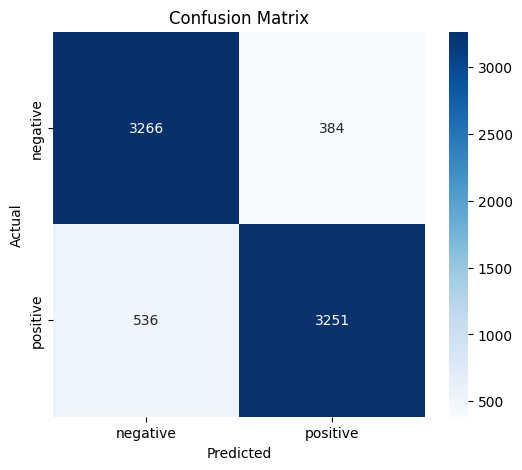

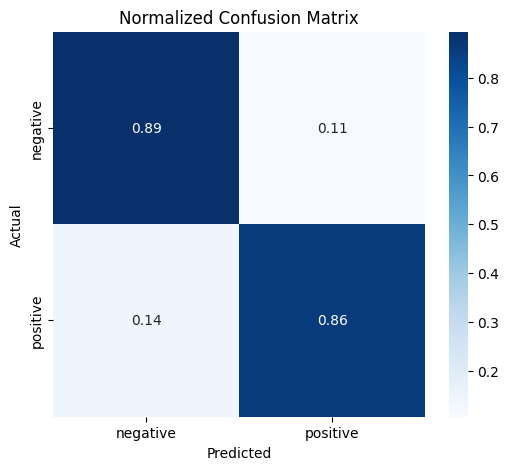

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix')
plt.show()

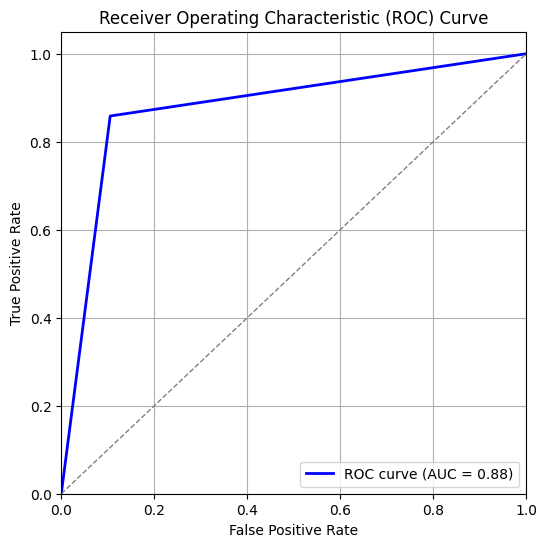

In [24]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()